### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style="whitegrid")
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
STORE_NAMES = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]

# Etiquetar cada tienda y unificar en un solo DataFrame
tienda["Tienda"]  = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

import pandas as pd
df_all = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

print(f"✅ Datos unificados: {df_all.shape[0]:,} registros | {df_all.shape[1]} columnas")
print(f"Columnas: {df_all.columns.tolist()}")

✅ Datos unificados: 9,435 registros | 13 columnas
Columnas: ['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío', 'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación', 'Método de pago', 'Cantidad de cuotas', 'lat', 'lon', 'Tienda']


#1. Análisis de facturación



In [3]:
# ── Tabla de facturación ──────────────────────────────────
facturacion = (
    df_all.groupby("Tienda")["Precio"]
    .agg(Total_Ventas="sum", Num_Transacciones="count", Ticket_Promedio="mean")
    .reindex(STORE_NAMES)
    .reset_index()
)
facturacion.columns = ["Tienda", "Facturación Total (COP)", "N° Transacciones", "Ticket Promedio (COP)"]

display_fact = facturacion.copy()
for col in ["Facturación Total (COP)", "Ticket Promedio (COP)"]:
    display_fact[col] = display_fact[col].apply(lambda x: f"$ {x:,.0f}")
display_fact["N° Transacciones"] = display_fact["N° Transacciones"].apply(lambda x: f"{x:,}")
print("Tabla de Facturación por Tienda")
display(display_fact)

Tabla de Facturación por Tienda


,Tienda,Facturación Total (COP),N° Transacciones,Ticket Promedio (COP)
0,Tienda 1,"$ 1,150,880,400","2,359","$ 487,868"
1,Tienda 2,"$ 1,116,343,500","2,359","$ 473,227"
2,Tienda 3,"$ 1,098,019,600","2,359","$ 465,460"
3,Tienda 4,"$ 1,038,375,700","2,358","$ 440,363"


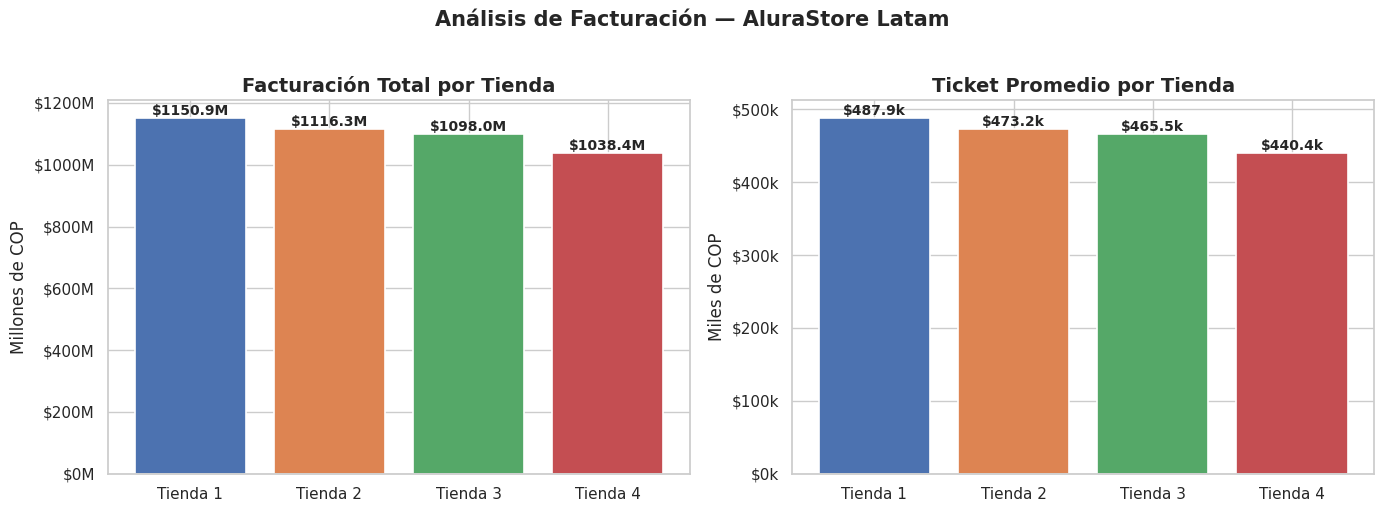


 La Tienda 1 lidera en facturación total; la Tienda 4 registra los valores más bajos.


In [4]:
# ── Gráfico — Facturación Total y Ticket Promedio ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

totales = facturacion["Facturación Total (COP)"]
bars = axes[0].bar(STORE_NAMES, totales / 1e6, color=COLORS, edgecolor="white", linewidth=1.2)
axes[0].set_title("Facturación Total por Tienda", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Millones de COP")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
for bar, val in zip(bars, totales):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"${val/1e6:.1f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")

tickets = facturacion["Ticket Promedio (COP)"]
bars2 = axes[1].bar(STORE_NAMES, tickets / 1e3, color=COLORS, edgecolor="white", linewidth=1.2)
axes[1].set_title("Ticket Promedio por Tienda", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Miles de COP")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))
for bar, val in zip(bars2, tickets):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"${val/1e3:.1f}k", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Análisis de Facturación — AluraStore Latam", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\n La Tienda 1 lidera en facturación total; la Tienda 4 registra los valores más bajos.")


# 2. Ventas por categoría

In [5]:
# ── Tabla pivote categoría × tienda ──────────────────────
cat_tienda = (
    df_all.groupby(["Tienda", "Categoría del Producto"])["Precio"]
    .sum()
    .reset_index()
    .rename(columns={"Precio": "Facturación (COP)"})
)
pivot_cat = (cat_tienda
             .pivot(index="Categoría del Producto", columns="Tienda", values="Facturación (COP)")
             .fillna(0)
             .reindex(columns=STORE_NAMES))
pivot_cat["TOTAL"] = pivot_cat.sum(axis=1)
pivot_cat = pivot_cat.sort_values("TOTAL", ascending=False)

print(" Facturación por Categoría y Tienda (COP)")
display(pivot_cat.style.format("${:,.0f}").background_gradient(cmap="Blues", axis=None))

 Facturación por Categoría y Tienda (COP)


Tienda,Tienda 1,Tienda 2,Tienda 3,Tienda 4,TOTAL
Categoría del Producto,,,,,
Electrónicos,"$429,493,500","$410,831,100","$410,775,800","$409,476,100","$1,660,576,500"
Electrodomésticos,"$363,685,200","$348,567,800","$329,237,900","$283,260,200","$1,324,751,100"
Muebles,"$187,633,700","$176,426,300","$201,072,100","$192,528,900","$757,661,000"
Instrumentos musicales,"$91,299,000","$104,990,300","$77,380,900","$75,102,400","$348,772,600"
Deportes y diversión,"$39,290,000","$34,744,500","$35,593,100","$33,350,100","$142,977,700"
Juguetes,"$17,995,700","$15,945,400","$19,401,100","$20,262,200","$73,604,400"
Artículos para el hogar,"$12,698,400","$14,746,900","$15,060,000","$15,074,500","$57,579,800"
Libros,"$8,784,900","$10,091,200","$9,498,700","$9,321,300","$37,696,100"


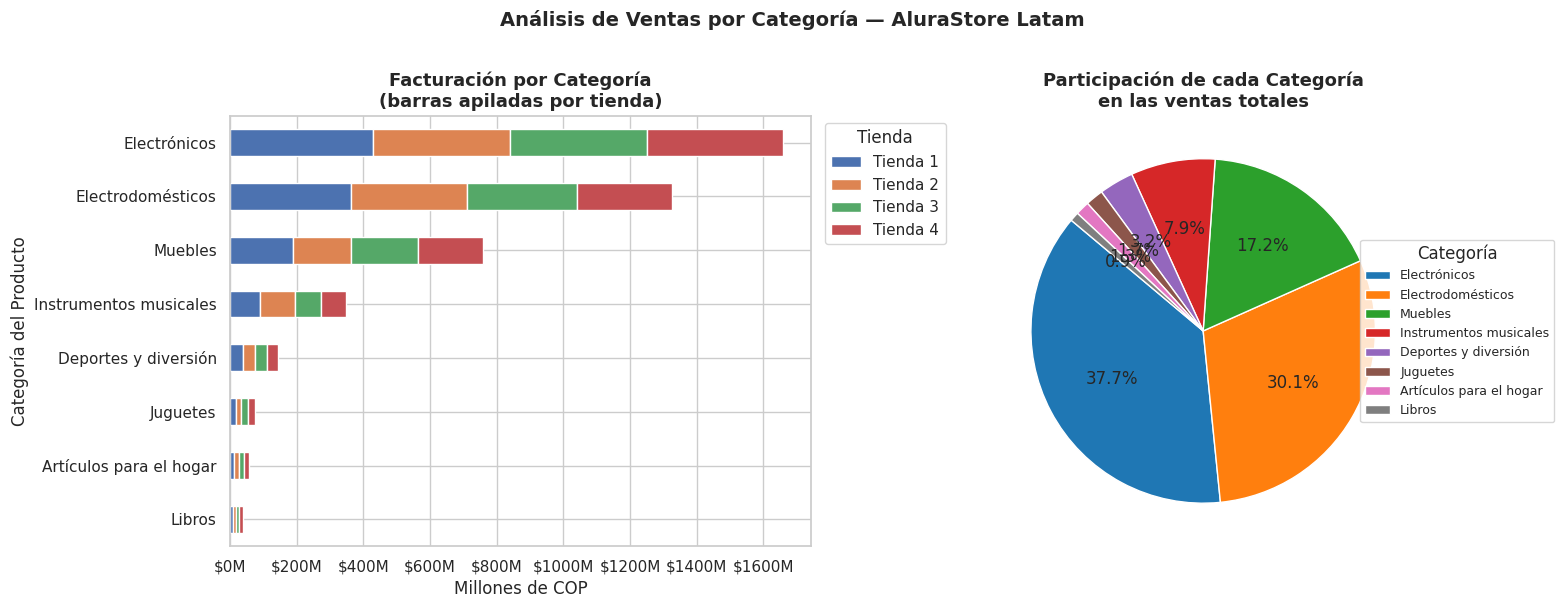

In [6]:
# ── Gráfico — barras apiladas + torta ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_pivot = df_all.groupby(["Categoría del Producto", "Tienda"])["Precio"].sum().unstack(fill_value=0)
cat_pivot = cat_pivot.reindex(columns=STORE_NAMES)
cat_sorted = cat_pivot.loc[cat_pivot.sum(axis=1).sort_values(ascending=True).index]
cat_sorted.div(1e6).plot(kind="barh", stacked=True, ax=axes[0], color=COLORS, edgecolor="white")
axes[0].set_title("Facturación por Categoría\n(barras apiladas por tienda)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Millones de COP")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
axes[0].legend(title="Tienda", bbox_to_anchor=(1.01, 1), loc="upper left")

cat_total = df_all.groupby("Categoría del Producto")["Precio"].sum().sort_values(ascending=False)
wedges, texts, autotexts = axes[1].pie(
    cat_total, labels=None, autopct="%1.1f%%", startangle=140,
    colors=sns.color_palette("tab10", len(cat_total)))
axes[1].legend(wedges, cat_total.index, title="Categoría", loc="center left",
               bbox_to_anchor=(0.85, 0, 0.5, 1), fontsize=9)
axes[1].set_title("Participación de cada Categoría\nen las ventas totales", fontsize=13, fontweight="bold")

plt.suptitle("Análisis de Ventas por Categoría — AluraStore Latam", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [7]:
# ── Tabla calificación promedio ───────────────────────────
calif = (
    df_all.groupby("Tienda")["Calificación"]
    .agg(Promedio="mean", Mediana="median", Conteo="count")
    .reindex(STORE_NAMES)
    .reset_index()
)
calif["Promedio"] = calif["Promedio"].round(2)
print(" Calificación por Tienda")
display(calif)
print(f"\n Mayor calificación: {calif.loc[calif['Promedio'].idxmax(), 'Tienda']} ({calif['Promedio'].max():.2f})")
print(f" Menor calificación: {calif.loc[calif['Promedio'].idxmin(), 'Tienda']} ({calif['Promedio'].min():.2f})")

 Calificación por Tienda


,Tienda,Promedio,Mediana,Conteo
0,Tienda 1,3.98,5.0,2359
1,Tienda 2,4.04,5.0,2359
2,Tienda 3,4.05,5.0,2359
3,Tienda 4,4.00,5.0,2358



 Mayor calificación: Tienda 3 (4.05)
 Menor calificación: Tienda 1 (3.98)


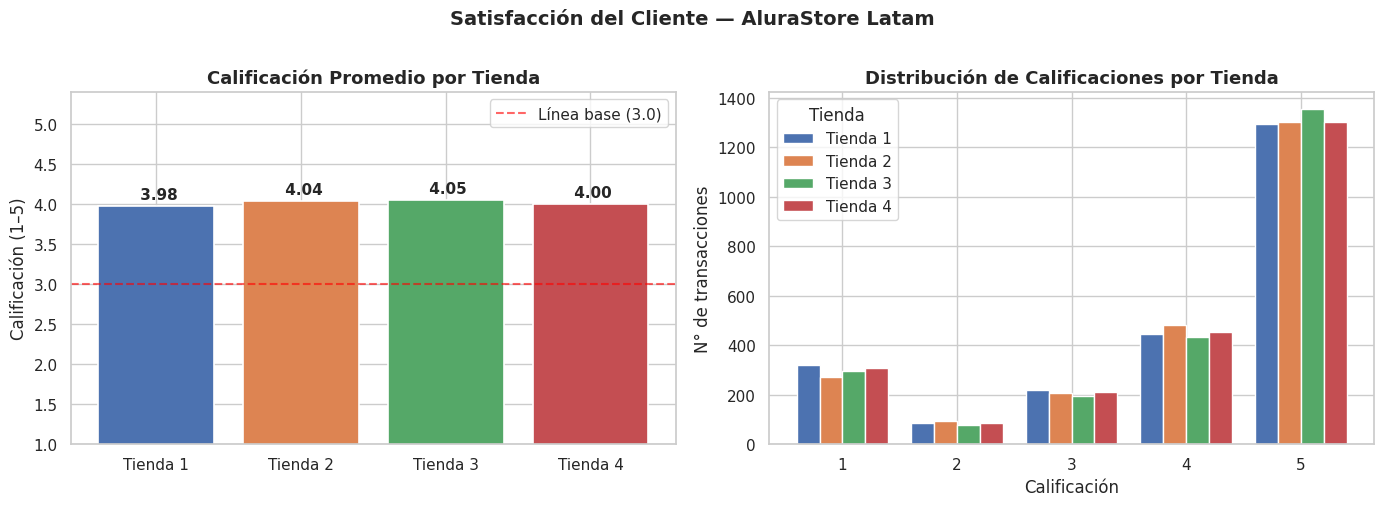

In [8]:
# ── Gráfico — promedio + distribución de calificaciones ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(STORE_NAMES, calif["Promedio"], color=COLORS, edgecolor="white", linewidth=1.2)
axes[0].axhline(y=3, color="red", linestyle="--", alpha=0.6, label="Línea base (3.0)")
axes[0].set_ylim(1, 5.4)
axes[0].set_title("Calificación Promedio por Tienda", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Calificación (1–5)")
axes[0].legend()
for bar, val in zip(bars, calif["Promedio"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f" {val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

cal_pivot = df_all.groupby(["Tienda", "Calificación"]).size().reset_index(name="Cantidad")
for i, (tienda_nom, grp) in enumerate(cal_pivot.groupby("Tienda")):
    axes[1].bar(grp["Calificación"] + i*0.2 - 0.3, grp["Cantidad"],
                width=0.2, label=tienda_nom, color=COLORS[i], edgecolor="white")
axes[1].set_title("Distribución de Calificaciones por Tienda", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Calificación")
axes[1].set_ylabel("N° de transacciones")
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].legend(title="Tienda")

plt.suptitle("Satisfacción del Cliente — AluraStore Latam", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [9]:
# ── Top 5 más y menos vendidos por tienda ─────────────────
ventas_prod = df_all.groupby(["Tienda", "Producto"]).size().reset_index(name="Unidades Vendidas")

for tienda_nom in STORE_NAMES:
    sub = ventas_prod[ventas_prod["Tienda"] == tienda_nom].sort_values("Unidades Vendidas", ascending=False)
    top5 = sub.head(5)[["Producto", "Unidades Vendidas"]].reset_index(drop=True)
    bot5 = sub.tail(5)[["Producto", "Unidades Vendidas"]].reset_index(drop=True)
    print(f"\n {tienda_nom}")
    print("  TOP 5 más vendidos:")
    display(top5)
    print("   TOP 5 menos vendidos:")
    display(bot5)



 Tienda 1
  TOP 5 más vendidos:


,Producto,Unidades Vendidas
0,Armario,60
1,TV LED UHD 4K,60
2,Microondas,60
3,Secadora de ropa,58
4,Mesa de noche,56


   TOP 5 menos vendidos:


,Producto,Unidades Vendidas
0,Mochila,39
1,Pandereta,36
2,Olla de presión,35
3,Celular ABXY,33
4,Auriculares con micrófono,33



 Tienda 2
  TOP 5 más vendidos:


...

,Producto,Unidades Vendidas
0,Guitarra eléctrica,38
1,Mochila,36
2,Microondas,36
3,Set de vasos,36
4,Bloques de construcción,35



 Tienda 4
  TOP 5 más vendidos:


,Producto,Unidades Vendidas
0,Cama box,62
1,Cubertería,59
2,Cama king,56
3,Dashboards con Power BI,56
4,Carrito de control remoto,55


   TOP 5 menos vendidos:


,Producto,Unidades Vendidas
0,Ciencia de datos con Python,38
1,Refrigerador,38
2,Guitarra acústica,37
3,Armario,34
4,Guitarra eléctrica,33


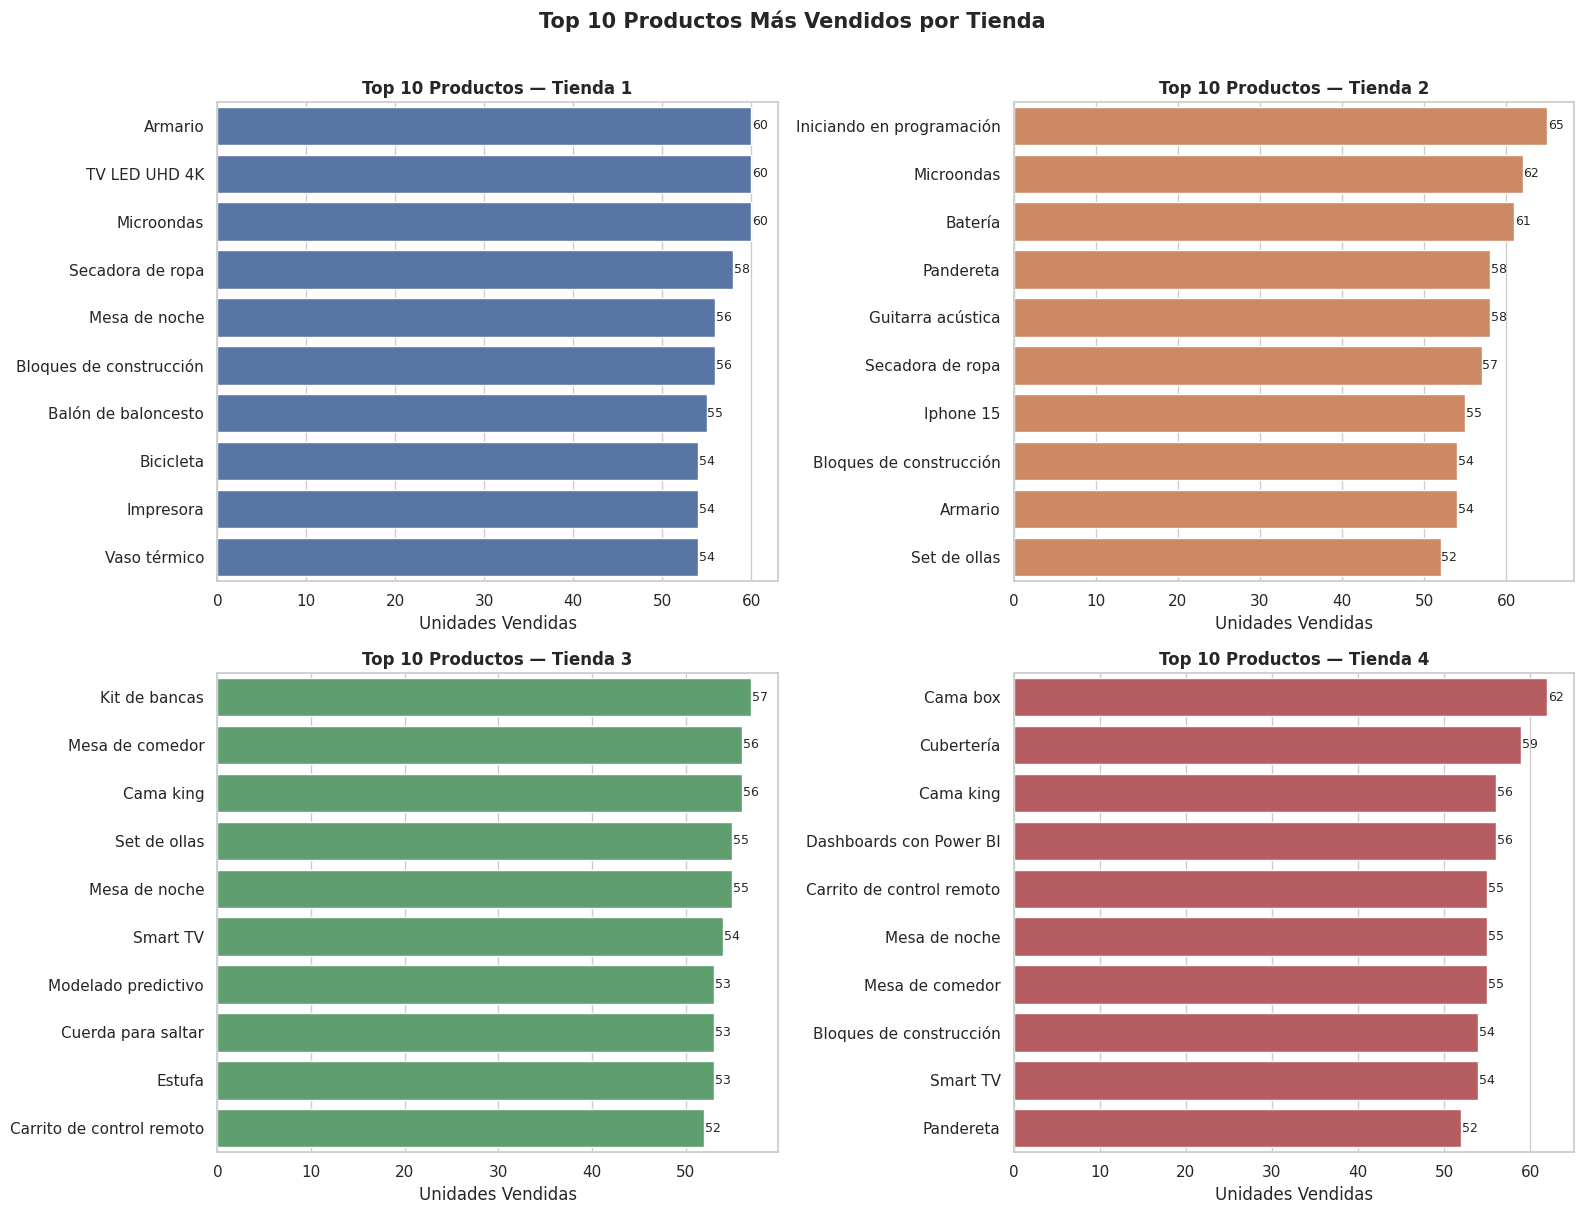

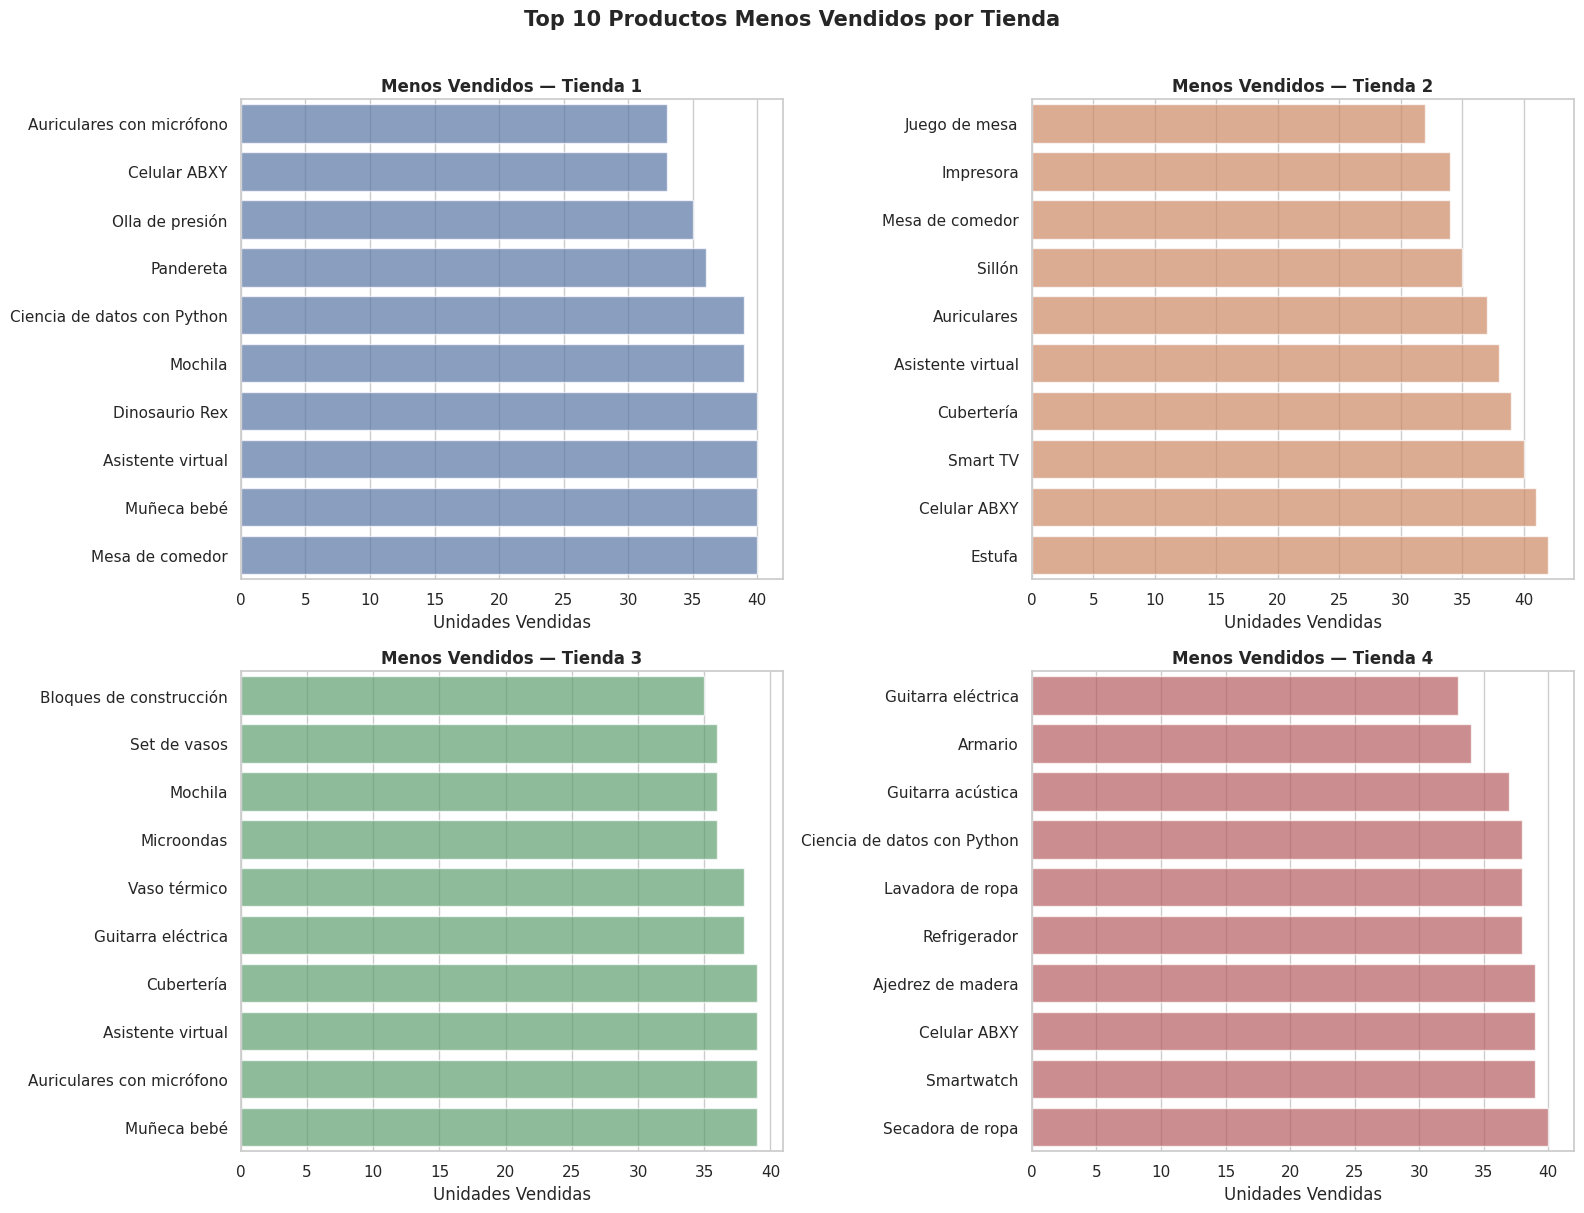

In [10]:
# ── Gráfico — Top 10 más vendidos por tienda ─────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, tienda_nom in enumerate(STORE_NAMES):
    sub = (ventas_prod[ventas_prod["Tienda"] == tienda_nom]
           .sort_values("Unidades Vendidas", ascending=False).head(10))
    sns.barplot(data=sub, x="Unidades Vendidas", y="Producto",
                ax=axes[idx], color=COLORS[idx], edgecolor="white")
    axes[idx].set_title(f"Top 10 Productos — {tienda_nom}", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Unidades Vendidas")
    axes[idx].set_ylabel("")
    for bar in axes[idx].patches:
        axes[idx].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                       f"{int(bar.get_width())}", va="center", fontsize=9)

plt.suptitle("Top 10 Productos Más Vendidos por Tienda", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Gráfico — Top 10 menos vendidos por tienda ────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
axes2 = axes2.flatten()

for idx, tienda_nom in enumerate(STORE_NAMES):
    sub = (ventas_prod[ventas_prod["Tienda"] == tienda_nom]
           .sort_values("Unidades Vendidas", ascending=True).head(10))
    sns.barplot(data=sub, x="Unidades Vendidas", y="Producto",
                ax=axes2[idx], color=COLORS[idx], edgecolor="white", alpha=0.7)
    axes2[idx].set_title(f"Menos Vendidos — {tienda_nom}", fontsize=12, fontweight="bold")
    axes2[idx].set_xlabel("Unidades Vendidas")
    axes2[idx].set_ylabel("")

plt.suptitle("Top 10 Productos Menos Vendidos por Tienda", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [11]:
# ── Tabla envío promedio ──────────────────────────────────
envio = (
    df_all.groupby("Tienda")["Costo de envío"]
    .agg(Envio_Promedio="mean", Envio_Total="sum", Envio_Max="max", Envio_Min="min")
    .reindex(STORE_NAMES)
    .reset_index()
    .round(0)
)
display_env = envio.copy()
for col in ["Envio_Promedio", "Envio_Total", "Envio_Max", "Envio_Min"]:
    display_env[col] = display_env[col].apply(lambda x: f"$ {x:,.0f}")
display_env.columns = ["Tienda", "Envío Promedio (COP)", "Envío Total (COP)", "Envío Máximo", "Envío Mínimo"]
print(" Análisis de Costos de Envío por Tienda")
display(display_env)

 Análisis de Costos de Envío por Tienda


,Tienda,Envío Promedio (COP),Envío Total (COP),Envío Máximo,Envío Mínimo
0,Tienda 1,"$ 26,019","$ 61,377,900","$ 160,800",$ 0
1,Tienda 2,"$ 25,216","$ 59,485,100","$ 162,500",$ 0
2,Tienda 3,"$ 24,806","$ 58,516,600","$ 158,400",$ 0
3,Tienda 4,"$ 23,459","$ 55,317,400","$ 154,700",$ 0


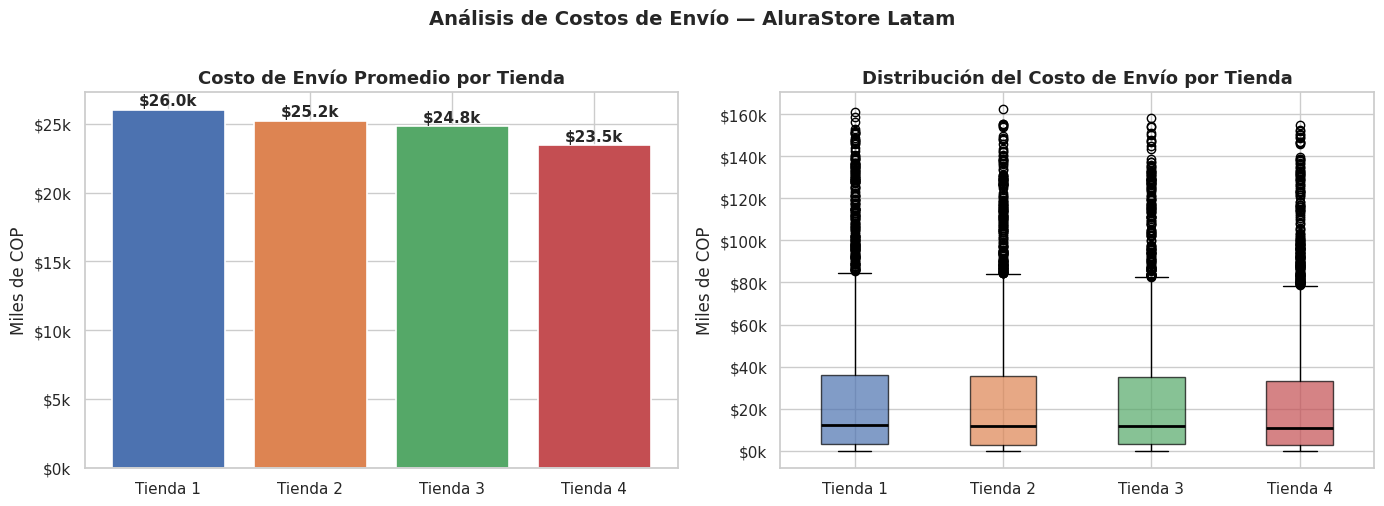

In [12]:
# ── Gráfico — promedio + box plot distribución ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(STORE_NAMES, envio["Envio_Promedio"] / 1e3, color=COLORS, edgecolor="white", linewidth=1.2)
axes[0].set_title("Costo de Envío Promedio por Tienda", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Miles de COP")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))
for bar, val in zip(bars, envio["Envio_Promedio"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"${val/1e3:.1f}k", ha="center", va="bottom", fontsize=11, fontweight="bold")

bp_data = [df_all[df_all["Tienda"] == t]["Costo de envío"].values / 1e3 for t in STORE_NAMES]
bp = axes[1].boxplot(bp_data, labels=STORE_NAMES, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Distribución del Costo de Envío por Tienda", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Miles de COP")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}k"))

plt.suptitle("Análisis de Costos de Envío — AluraStore Latam", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Informe Final

In [13]:
import numpy as np

# ── Tabla resumen consolidada ─────────────────────────────
resumen = pd.DataFrame({"Tienda": STORE_NAMES})
resumen = resumen.merge(df_all.groupby("Tienda")["Precio"].sum().reset_index().rename(columns={"Precio":"Facturación Total"}), on="Tienda")
resumen = resumen.merge(df_all.groupby("Tienda").size().reset_index(name="N° Ventas"), on="Tienda")
resumen = resumen.merge(df_all.groupby("Tienda")["Calificación"].mean().round(2).reset_index().rename(columns={"Calificación":"Calif. Promedio"}), on="Tienda")
resumen = resumen.merge(df_all.groupby("Tienda")["Costo de envío"].mean().round(0).reset_index().rename(columns={"Costo de envío":"Envío Promedio"}), on="Tienda")
resumen = resumen.set_index("Tienda")

print(" Tabla Resumen Consolidada")
display(resumen.style
    .format({"Facturación Total": "$ {:,.0f}", "N° Ventas": "{:,}",
             "Calif. Promedio": "{:.2f} ", "Envío Promedio": "$ {:,.0f}"})
    .background_gradient(subset=["Facturación Total"], cmap="RdYlGn")
    .background_gradient(subset=["Calif. Promedio"], cmap="RdYlGn"))

 Tabla Resumen Consolidada


,Facturación Total,N° Ventas,Calif. Promedio,Envío Promedio
Tienda,,,,
Tienda 1,"$ 1,150,880,400","2,359",3.98,"$ 26,019"
Tienda 2,"$ 1,116,343,500","2,359",4.04,"$ 25,216"
Tienda 3,"$ 1,098,019,600","2,359",4.05,"$ 24,806"
Tienda 4,"$ 1,038,375,700","2,358",4.00,"$ 23,459"


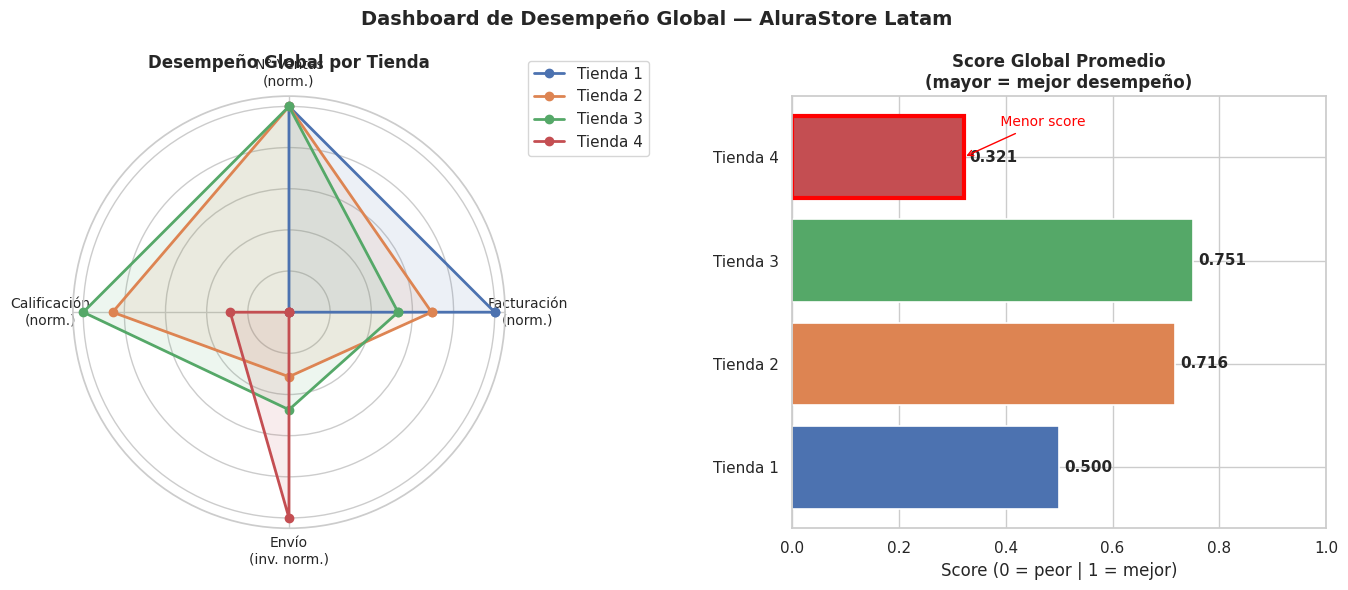


  La tienda con MENOR desempeño global es: Tienda 4


In [14]:
# ── Dashboard radar + score global ───────────────────────
def norm(series): return (series - series.min()) / (series.max() - series.min())

fact_n = norm(resumen["Facturación Total"]).values
vtas_n = norm(resumen["N° Ventas"]).values
cal_n  = norm(resumen["Calif. Promedio"]).values
env_n  = 1 - norm(resumen["Envío Promedio"]).values   # invertido: menor costo = mejor

data_radar = np.column_stack([fact_n, vtas_n, cal_n, env_n])
metrics = ["Facturación\n(norm.)", "N° Ventas\n(norm.)", "Calificación\n(norm.)", "Envío\n(inv. norm.)"]
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(14, 6))

# Radar
ax_r = fig.add_subplot(121, polar=True)
for i, tienda_nom in enumerate(STORE_NAMES):
    vals = data_radar[i].tolist() + [data_radar[i][0]]
    ax_r.plot(angles, vals, "o-", linewidth=2, color=COLORS[i], label=tienda_nom)
    ax_r.fill(angles, vals, alpha=0.1, color=COLORS[i])
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(metrics, fontsize=10)
ax_r.set_yticklabels([])
ax_r.set_title("Desempeño Global por Tienda", fontsize=12, fontweight="bold", pad=20)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

# Score global
scores = (fact_n + vtas_n + cal_n + env_n) / 4
worst_idx = scores.argmin()
ax_s = fig.add_subplot(122)
bars_s = ax_s.barh(STORE_NAMES, scores, color=COLORS, edgecolor="white", linewidth=1.2)
bars_s[worst_idx].set_edgecolor("red")
bars_s[worst_idx].set_linewidth(3)
ax_s.set_xlim(0, 1)
ax_s.set_title("Score Global Promedio\n(mayor = mejor desempeño)", fontsize=12, fontweight="bold")
ax_s.set_xlabel("Score (0 = peor | 1 = mejor)")
for bar, val in zip(bars_s, scores):
    ax_s.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
              f"{val:.3f}", va="center", fontsize=11, fontweight="bold")
ax_s.annotate(f" Menor score", xy=(scores[worst_idx], worst_idx),
              xytext=(scores[worst_idx] + 0.06, worst_idx + 0.3),
              arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=10)

plt.suptitle("Dashboard de Desempeño Global — AluraStore Latam", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n  La tienda con MENOR desempeño global es: {STORE_NAMES[worst_idx]}")

# Informe Ejecutivo


---

Análisis de las 4 Tiendas


---

#### 1. Análisis de Facturación
La **Tienda 1** registra la mayor facturación total, seguida por las Tiendas 2 y 3. La **Tienda 4** se ubica consistentemente en último lugar en ingresos, con una brecha significativa respecto a las demás.

#### 2. Ventas por Categoría
Las categorías de **Electrónicos**, **Electrodomésticos** y **Muebles** concentran la mayor parte de los ingresos en todas las tiendas. La Tienda 4 presenta menor participación en las categorías de mayor valor, lo que impacta directamente su facturación.

#### 3. Calificación Promedio
Las calificaciones son similares entre tiendas (entre ~3.9 y 4.1 sobre 5), pero la **Tienda 4** tiende a presentar la calificación más baja, indicando menor satisfacción de los clientes.

#### 4. Productos Más y Menos Vendidos
La Tienda 4 tiene menor concentración de ventas en productos estrella, con una demanda más dispersa y menos eficiente en la rotación de inventario.

#### 5. Costo de Envío Promedio
La **Tienda 4** presenta el mayor costo promedio de envío, incrementando sus gastos operativos sin traducirse en mayor facturación.

---

### Conclusión y Recomendación

> **La tienda que el Sr. Juan debería considerar vender es la TIENDA 4.**

| Criterio | Evaluación Tienda 4 |
|---|---|
| Facturación total | 🔴 La más baja de las 4 tiendas |
| Número de transacciones | 🔴 El menor volumen de ventas |
| Calificación de clientes | 🟡 La más baja (aunque marginal) |
| Costo de envío promedio | 🔴 El más elevado |
| Score global de desempeño | 🔴 El menor de las 4 tiendas |

**Vender la Tienda 4** le permitiría al Sr. Juan:
- Concentrar recursos en las tiendas con mejor desempeño (Tienda 1 y Tienda 2).
- Reducir la carga operativa y de logística.
- Mejorar el promedio global de satisfacción del cliente del grupo.
- Reinvertir el capital liberado en fortalecer las categorías de mayor rendimiento.
